In [1]:
import pandas as pd
import numpy as np


import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

In [2]:
!ls results/DLinear

 32_20_overlapping_0_strides.csv
 32_20_overlapping_1_strides.csv
 32_20_overlapping_2_strides.csv
 32_20_overlapping_3_strides.csv
 32_20_overlapping_4_strides.csv
 32_disjoint_0.csv
 32_disjoint_0_test.csv
 32_disjoint_1.csv
 32_disjoint_2.csv
 32_disjoint_3.csv
 32_disjoint_4.csv
 32_MSE_0.csv
 32_MSE_0_test.csv
 32_MSE_1.csv
 32_MSE_2.csv
 32_MSE_3.csv
 32_MSE_4.csv
 32_overlapping_0.csv
 32_overlapping_0_test.csv
 32_overlapping_1.csv
 32_overlapping_2.csv
 32_overlapping_3.csv
 32_overlapping_4.csv
 disjoint.csv
' disjoint_short.csv'
 ensemble_32_150_disjoint_noschedule_test.csv
 ensemble_32_150_overlapping_noschedule_test.csv
 ensemble_32_20_disjoint.csv
 ensemble_32_20_disjoint_noschedule_test.csv
 ensemble_32_20_overlapping.csv
 ensemble_32_20_overlapping_noschedule.csv
 ensemble_32_20_overlapping_noschedule_test.csv
 ensemble_ML_1024_20_overlapping.csv
 ensemble_ML_128_20_overlapping.csv
 ensemble_ML_256_20_overlapping.csv
 ensemble_ML_512_20_overlapping.csv
 mean_bfgs_short.

In [3]:
name = "Transformer"
res_dis = []
res_over = []
for seed in range(5):
    res_dis.append(pd.read_csv(f"results/{name}/ucr_32_disjoint_{seed}.csv")["score"].mean())
    res_over.append(pd.read_csv(f"results/{name}/ucr_32_overlapping_{seed}.csv")["score"].mean())
print(name)
print(f"Overlapping: {np.mean(res_over)*100:.1f} +- {np.std(res_over)*100:.1f} ")
print(f"Disjoint: {np.mean(res_dis)*100:.1f} +- {np.std(res_dis)*100:.1f} ")

Transformer
Overlapping: 21.3 +- 0.9 
Disjoint: 17.7 +- 1.8 


In [4]:
name = "TimesNet"
mtr = "AUC-PR"
for metr in ["AUC-PR", "AUC-ROC", "Standard-F1"]:
    res_dis = []
    res_over = []
    for seed in range(5):
        res_dis.append(pd.read_csv(f"results/{name}/32_disjoint_{seed}.csv")[metr].mean())
        res_over.append(pd.read_csv(f"results/{name}/32_overlapping_{seed}.csv")[metr].mean())
    print(metr)
    print(f"Overlapping: {np.mean(res_over)*100:.1f} +- {np.std(res_over)*100:.1f} ")
    print(f"Disjoint: {np.mean(res_dis)*100:.1f} +- {np.std(res_dis)*100:.1f} ")
    print()

AUC-PR
Overlapping: 49.3 +- 0.1 
Disjoint: 41.9 +- 0.2 

AUC-ROC
Overlapping: 82.2 +- 0.1 
Disjoint: 77.3 +- 0.1 

Standard-F1
Overlapping: 52.2 +- 0.1 
Disjoint: 45.4 +- 0.2 



In [10]:
name = "Linear"
n_seeds = 5

for metr in ["AUC-PR", "AUC-ROC", "Standard-F1"]:
    # Load all seeds
    dis_rows = []
    over_rows = []

    for seed in range(n_seeds):
        dis = pd.read_csv(f"results/{name}/32_disjoint_{seed}.csv")[metr]
        over = pd.read_csv(f"results/{name}/32_overlapping_{seed}.csv")[metr]

        dis_rows.append(dis.values)
        over_rows.append(over.values)

    # Shape: (n_seeds, n_rows)
    dis_arr = np.stack(dis_rows, axis=0)
    over_arr = np.stack(over_rows, axis=0)

    # Row-wise statistics across seeds
    dis_row_mean = dis_arr.mean(axis=0)
    dis_row_std  = dis_arr.std(axis=0)

    over_row_mean = over_arr.mean(axis=0)
    over_row_std  = over_arr.std(axis=0)

    # Global mean over rows
    dis_global_mean = dis_row_mean.mean()
    dis_global_std  = dis_row_std.mean()

    over_global_mean = over_row_mean.mean()
    over_global_std  = over_row_std.mean()

    print(metr)
    print(
        f"Overlapping: "
        f"{over_global_mean*100:.1f} ± {over_global_std*100:.1f}"
    )
    print(
        f"Disjoint:    "
        f"{dis_global_mean*100:.1f} ± {dis_global_std*100:.1f}\n"
    )

ValueError: all input arrays must have the same shape

In [11]:
name = "DLinear"
n_seeds = 5

for stride in [1, 2 ,8, 16]:
    print("Stride: ", stride)

    for metr in ["AUC-PR", "AUC-ROC", "Standard-F1", "inference_time"]:
        # Load all seeds
        dis_rows = []
        over_rows = []
    
        for seed in range(n_seeds):
            over = pd.read_csv(f"results/{name}/32_20_overlapping_{seed}_strides.csv")
            over = over[over["stride"] == stride]
            over_rows.append(over[metr].values[61])
    
        over_arr = np.stack(over_rows, axis=0)
        over_row_mean = over_arr.mean(axis=0)
        over_row_std  = over_arr.std(axis=0)
    
        over_global_mean = over_row_mean.mean()
        over_global_std  = over_row_std.mean()

        print(f"\t{metr}: {over_global_mean*100:.1f} ± {over_global_std*100:.1f}")
   

Stride:  1
	AUC-PR: 43.4 ± 0.2
	AUC-ROC: 90.9 ± 0.1
	Standard-F1: 47.4 ± 0.2
	inference_time: 4.3 ± 0.1
Stride:  2
	AUC-PR: 43.2 ± 0.3
	AUC-ROC: 91.0 ± 0.2
	Standard-F1: 46.9 ± 0.5
	inference_time: 2.2 ± 0.0
Stride:  8
	AUC-PR: 40.2 ± 0.5
	AUC-ROC: 87.6 ± 0.4
	Standard-F1: 45.4 ± 1.0
	inference_time: 0.7 ± 0.0
Stride:  16
	AUC-PR: 38.2 ± 0.1
	AUC-ROC: 84.2 ± 0.6
	Standard-F1: 44.5 ± 0.5
	inference_time: 0.4 ± 0.0


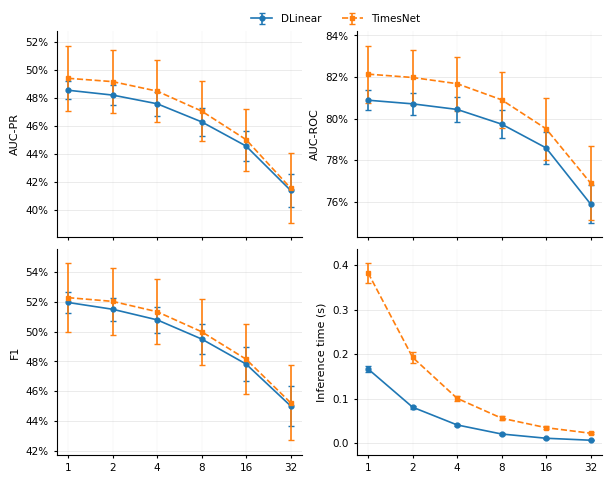

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

names = ["DLinear", "TimesNet"]
n_seeds = 5
strides = [1, 2, 4, 8, 16, 32]
metrics_grid = [
    ("AUC-PR",        "AUC-PR",   True),
    ("AUC-ROC",       "AUC-ROC",  True),
    ("Standard-F1",   "F1",       True),
    ("inference_time","Inference time (s)", False),
]

def collect_results(name, n_seeds, strides, metrics):
    rows = []
    for stride in strides:
        for metr in metrics:
            over_rows = []

            for seed in range(n_seeds):
                over = pd.read_csv(f"results/{name}/32_20_overlapping_{seed}_strides.csv")
                over = over[over["stride"] == stride]
                over_rows.append(over[metr].values)

            over_arr = np.stack(over_rows, axis=0)
            over_row_mean = over_arr.mean(axis=0)
            over_row_std  = over_arr.std(axis=0)
    
            over_global_mean = over_row_mean.mean()
            over_global_std  = over_row_std.mean()
                
            rows.append({
                "model": name,
                "stride": stride,
                "metric": metr,
                "mean": over_global_mean,
                "std":  over_global_std
            })
    return pd.DataFrame(rows)

metrics = [m for m, _, _ in metrics_grid]
res = pd.concat([collect_results(n, n_seeds, strides, metrics) for n in names], ignore_index=True)

# ----- Plot (ECAI-ish: compact, 2x2) -----
plt.rcParams.update({
    "font.size": 8,
    "axes.titlesize": 8.5,
    "axes.labelsize": 8,
    "xtick.labelsize": 7.5,
    "ytick.labelsize": 7.5,
    "legend.fontsize": 7.5,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

pct = FuncFormatter(lambda x, pos: f"{x:.0f}%")

fig, axes = plt.subplots(2, 2, figsize=(6, 4.5), layout="constrained",sharex=True)
axes = axes.ravel()

def style(ax):
    ax.set_xscale("log", base=2)
    ax.set_xticks(strides, labels=[str(s) for s in strides])
    ax.grid(True, axis="y", linewidth=0.5, alpha=0.35)
    ax.grid(True, axis="x", linewidth=0.3, alpha=0.20)
    ax.tick_params(length=2.5, width=0.8)

linestyles = {"DLinear": "-", "TimesNet": "--", "iTransformer": "-."}
markers    = {"DLinear": "o", "TimesNet": "s", "iTransformer": "*"}

for ax, (metr, ylabel, is_pct) in zip(axes, metrics_grid):
    for model in names:
        dfm = res[(res["metric"] == metr) & (res["model"] == model)].sort_values("stride")
        x = dfm["stride"].to_numpy()
        y = dfm["mean"].to_numpy()
        e = dfm["std"].to_numpy()

        if is_pct:
            y, e = 100*y, 100*e
            ax.yaxis.set_major_formatter(pct)

        ax.errorbar(
            x, y, yerr=e,
            fmt=markers[model] + linestyles[model],
            capsize=2.5, linewidth=1.2, markersize=3.5,
            label=model
        )

    ax.set_ylabel(ylabel)
    style(ax)

    df_all = res[res["metric"] == metr].sort_values("stride")
    y_all = df_all["mean"].to_numpy()
    e_all = df_all["std"].to_numpy()
    if is_pct:
        y_all, e_all = 100*y_all, 100*e_all
    ymin = np.min(y_all - e_all)
    ymax = np.max(y_all + e_all)
    pad = 0.08 * (ymax - ymin if ymax > ymin else 1.0)
    ax.set_ylim(ymin - pad, ymax + pad)



handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, frameon=False, bbox_to_anchor=(0.55, 1.05))

fig.savefig("stride_sweep.pdf", bbox_inches="tight")
plt.show()


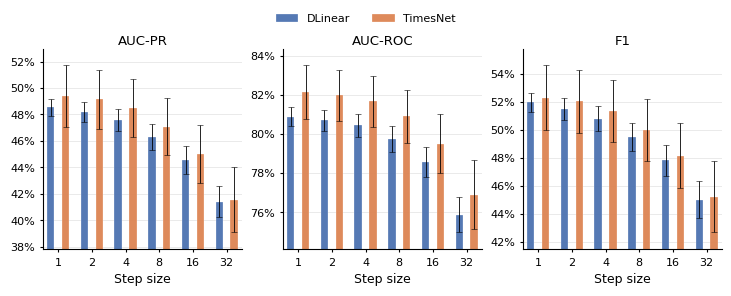

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# ---------- Prettier style ----------
plt.rcParams.update({
    "font.size": 8.5,
    "axes.titlesize": 9.5,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 0.8,
})

pct = FuncFormatter(lambda x, pos: f"{x:.0f}%")

# 1x3 since inference time removed
fig, axes = plt.subplots(1, 3, figsize=(7.2, 2.6), layout="constrained", sharex=True)
axes = np.atleast_1d(axes).ravel()

# ---------- grouped-bar geometry ----------
xpos = np.arange(len(strides))
bar_w = 0.22
offsets = np.linspace(-bar_w, bar_w, len(names))

# better model styling
model_colors = {
    "DLinear": "#4C72B0",        # blue
    "TimesNet": "#DD8452",      # orange
    "iTransformer": "#55A868",  # green
}

def style(ax):
    ax.set_axisbelow(True)
    ax.grid(True, axis="y", linewidth=0.6, alpha=0.30)
    ax.grid(False, axis="x")
    ax.tick_params(length=2.5, width=0.8)
    ax.margins(x=0.02)

for ax, (metr, ylabel, is_pct) in zip(axes, metrics_grid):
    for model, off in zip(names, offsets):
        dfm = res[(res["metric"] == metr) & (res["model"] == model)].sort_values("stride")
        y = dfm["mean"].to_numpy()
        e = dfm["std"].to_numpy()

        if is_pct:
            y, e = 100 * y, 100 * e
            ax.yaxis.set_major_formatter(pct)

        ax.bar(
            xpos + off, y,
            width=bar_w,
            yerr=e,
            capsize=2.2,
            color=model_colors[model],
            edgecolor="white",
            linewidth=0.2,
            alpha=0.95,
            label=model,
            error_kw=dict(elinewidth=0.6, capthick=0.4) 
        )

    # labels + cosmetics
    ax.set_title(ylabel, pad=3)
    ax.set_ylabel("")  # only left subplot gets y-label
    ax.set_xticks(xpos, labels=[str(s) for s in strides])
    ax.set_xlabel("Step size")
    style(ax)

    # y-lim with padding (includes error bars)
    df_all = res[res["metric"] == metr].sort_values("stride")
    y_all = df_all["mean"].to_numpy()
    e_all = df_all["std"].to_numpy()
    if is_pct:
        y_all, e_all = 100 * y_all, 100 * e_all
    ymin = np.min(y_all - e_all)
    ymax = np.max(y_all + e_all)
    pad = 0.10 * (ymax - ymin if ymax > ymin else 1.0)
    ax.set_ylim(ymin - pad, ymax + pad)

# ---------- legend (centered above, no wasted space) ----------
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, frameon=False, bbox_to_anchor=(0.5, 1.10))

# ---------- save ----------
fig.savefig("stride_sweep_bar.png", bbox_inches="tight")
plt.show()


In [14]:
name="TimesNet"
stride = 1
for seed in range(5):
    print(f"Seed {seed}")
    
    for metr in ["AUC-PR", "AUC-ROC", "Standard-F1", "inference_time"]:
    
    
        over = pd.read_csv(f"results/{name}/32_20_overlapping_{seed}_strides.csv")
        over = over[over["stride"] == stride]
        over_arr = over[metr].values[61]
        print(f"\t{metr}: {over_arr.mean()*100:.1f}")


Seed 0
	AUC-PR: 50.3
	AUC-ROC: 96.1
	Standard-F1: 55.7
	inference_time: 14.3
Seed 1
	AUC-PR: 44.8
	AUC-ROC: 94.6
	Standard-F1: 48.8
	inference_time: 21.5
Seed 2
	AUC-PR: 34.5
	AUC-ROC: 93.4
	Standard-F1: 35.5
	inference_time: 22.3
Seed 3
	AUC-PR: 50.1
	AUC-ROC: 93.7
	Standard-F1: 52.3
	inference_time: 22.3
Seed 4
	AUC-PR: 48.8
	AUC-ROC: 94.3
	Standard-F1: 54.6
	inference_time: 21.9


In [15]:
name = "TimesNet"
i = 61
stride = 1
for seed in range(5):
    print(f"Seed {seed}")
    for metr in ["AUC-PR", "AUC-ROC", "Standard-F1"]:
    
    
        over = pd.read_csv(f"results/TimesNet/32_20_overlapping_{seed}_strides.csv")
        over = over[over["stride"] == stride]
        metr_timesnet = over[metr].values[i]

        over = pd.read_csv(f"results/DLinear/32_20_overlapping_{seed}_strides.csv")
        over = over[over["stride"] == stride]
        metr_itrans = over[metr].values[i]
        print(f"\t{metr}: {(metr_timesnet-metr_itrans)*100:.1f}")

Seed 0
	AUC-PR: 7.2
	AUC-ROC: 5.2
	Standard-F1: 8.6
Seed 1
	AUC-PR: 1.4
	AUC-ROC: 3.6
	Standard-F1: 1.2
Seed 2
	AUC-PR: -8.9
	AUC-ROC: 2.3
	Standard-F1: -11.8
Seed 3
	AUC-PR: 6.6
	AUC-ROC: 2.7
	Standard-F1: 4.8
Seed 4
	AUC-PR: 5.1
	AUC-ROC: 3.6
	Standard-F1: 7.2


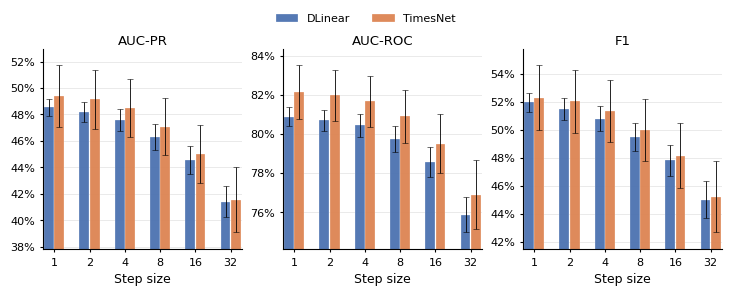

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# ---------- Prettier style ----------
plt.rcParams.update({
    "font.size": 8.5,
    "axes.titlesize": 9.5,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 0.8,
})

pct = FuncFormatter(lambda x, pos: f"{x:.0f}%")

# 1x3 since inference time removed
fig, axes = plt.subplots(1, 3, figsize=(7.2, 2.6), layout="constrained", sharex=True)
axes = np.atleast_1d(axes).ravel()

# ---------- grouped-bar geometry ----------
xpos = np.arange(len(strides))

# tighten spacing inside each stride group
bar_w = 0.28      # wider bars => less empty space
gap = 0.01        # set to 0.0 to make bars touch
step = bar_w + gap

k = len(names)
offsets = (np.arange(k) - (k - 1) / 2) * step

# better model styling
model_colors = {
    "DLinear": "#4C72B0",        # blue
    "TimesNet": "#DD8452",       # orange
    "iTransformer": "#55A868",   # green
}

def style(ax):
    ax.set_axisbelow(True)
    ax.grid(True, axis="y", linewidth=0.6, alpha=0.30)
    ax.grid(False, axis="x")
    ax.tick_params(length=2.5, width=0.8)
    ax.margins(x=0.005)  # tighter group margins

for ax, (metr, ylabel, is_pct) in zip(axes, metrics_grid):
    for model, off in zip(names, offsets):
        dfm = res[(res["metric"] == metr) & (res["model"] == model)].sort_values("stride")
        y = dfm["mean"].to_numpy()
        e = dfm["std"].to_numpy()

        if is_pct:
            y, e = 100 * y, 100 * e
            ax.yaxis.set_major_formatter(pct)

        ax.bar(
            xpos + off, y,
            width=bar_w,
            yerr=e,
            capsize=2.2,
            color=model_colors[model],
            edgecolor="white",
            linewidth=0.2,
            alpha=0.95,
            label=model,
            error_kw=dict(elinewidth=0.6, capthick=0.4)
        )

    # labels + cosmetics
    ax.set_title(ylabel, pad=3)
    ax.set_ylabel("")  # only left subplot gets y-label
    ax.set_xticks(xpos, labels=[str(s) for s in strides])
    ax.set_xlabel("Step size")
    style(ax)

    # y-lim with padding (includes error bars)
    df_all = res[res["metric"] == metr].sort_values("stride")
    y_all = df_all["mean"].to_numpy()
    e_all = df_all["std"].to_numpy()
    if is_pct:
        y_all, e_all = 100 * y_all, 100 * e_all
    ymin = np.min(y_all - e_all)
    ymax = np.max(y_all + e_all)
    pad = 0.10 * (ymax - ymin if ymax > ymin else 1.0)
    ax.set_ylim(ymin - pad, ymax + pad)

# ---------- legend (centered above, no wasted space) ----------
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, frameon=False, bbox_to_anchor=(0.5, 1.10))

# ---------- save ----------
fig.savefig("stride_sweep_bar.png", bbox_inches="tight")
plt.show()
